In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from river.decomposition import OnlineDMDwC
from river.feature_extraction import PolynomialExtender
from river.preprocessing import Hankelizer
from tqdm import tqdm

sys.path.append("../")

from functions.chdsubid import (
    SubIDChangeDetector,
    get_default_rank,
    get_default_timedelays,
)
from functions.plot import plot_chd
from functions.preprocessing import hankel, polynomial_extension
from functions.rolling import Rolling

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Read data
hm = 1
train_data = pd.read_pickle("data/nonlinear-delay-control/train_sim.pkl")  # noqa: S301  # trusted local pickle generated by this project
X = pd.DataFrame(train_data["X"][:12000])
U = pd.DataFrame(train_data["U"][:12000])
Y = np.zeros(X.shape[0])

# Introduce gaussian noise
np.random.seed(42)
noise = 0.1
X += np.random.normal(0, noise, X.shape)

# Introduce step reduction in response amplitude
X[3998:4998] += 1.0
Y[3998:4998] = 1

# Introduce step reduction in response amplitude
X[7598:8598] *= 2.0
Y[7598:8598] = 1

# Introduce gradual reduction in responsiveness from 1.0 to 0.25
X[9798:12000] *= np.linspace(1.0, 2.0, X[9798:12000].shape[0])[:, None]
Y[9798:12000] = 1

# X[14998:] += np.linspace(0.0, 1.0, X[14998:].shape[0])[:, None]
# Y[14998:] = 1

In [ ]:
n, m = X.shape
n_inputs_in_ = U.shape[1]

window_size: int = 2000
# Base size
ref_size = 200
test_size = 200

m_ext = 2
X_ = polynomial_extension(X, m_ext)
# If window_size is not very large, then take half
hm, hm_step = get_default_timedelays(200)
hl, hl_step = get_default_timedelays(30, 30 // U.shape[1])
# Optimal low-rank representation of signal with unknown noise variance
p = get_default_rank(hankel(X_[:window_size], hm, hm_step), noise)
print(f"Optimal rank for states is: {p}")
q = get_default_rank(hankel(U[:window_size], hl, hl_step), 0)
q = 2
print(f"Optimal rank for inputs is: {q}")

Snapshots processed:   0%|          | 0/12000 [00:00<?, ?it/s]

Snapshots processed:  17%|█▋        | 2000/12000 [00:01<00:05, 1736.54it/s]

Snapshots processed:  17%|█▋        | 2000/12000 [00:20<00:05, 1736.54it/s]

Snapshots processed:  22%|██▏       | 2660/12000 [00:20<01:29, 104.73it/s] 

Snapshots processed:  22%|██▏       | 2695/12000 [00:21<01:33, 99.59it/s] 

...

Snapshots processed:  99%|█████████▉| 11864/12000 [04:44<00:04, 32.71it/s]

Snapshots processed:  99%|█████████▉| 11898/12000 [04:46<00:03, 31.53it/s]

Snapshots processed:  99%|█████████▉| 11934/12000 [04:47<00:02, 32.63it/s]

Snapshots processed: 100%|█████████▉| 11970/12000 [04:48<00:00, 33.38it/s]

Snapshots processed: 100%|██████████| 12000/12000 [04:49<00:00, 41.47it/s]

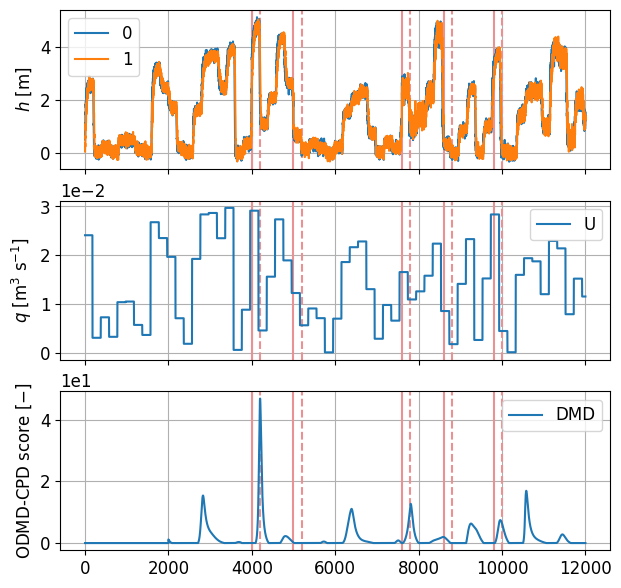

In [ ]:
# [donotremove]
# TODO: enable hankelization of us on the fly
U_ = pd.DataFrame(hankel(U, hl, hl_step))

# Initialize Hankelizer
hankelizer = Hankelizer(hm)

# Initialize Transformer
init_size = window_size
odmd = Rolling(
    OnlineDMDwC(
        p=p,
        q=q,
        initialize=init_size - 1,
        w=1.0,
        exponential_weighting=False,
        eig_rtol=None,
    ),
    init_size,
)

# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size,
    start_soon=True,
    # learn_after_grace=False,
)

# Build pipeline
pipeline_dmd = PolynomialExtender(m_ext) | hankelizer | subid_dmd

# Prepare arrays for storing results
scores_dmd = np.zeros(n, dtype=float)
scores_dmd_diff = np.zeros(n, dtype=complex)
dist = np.zeros((n, 2), dtype=complex)
modes = np.empty((n, hm * m, p), dtype=complex)
X_h = []
X_tilde = []

# Run pipeline
for i, (x, u) in tqdm(
    enumerate(
        zip(
            X.to_dict(orient="records"),
            U_.to_dict(orient="records"),
            strict=False,
        ),
    ),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    X_h.append(hankelizer.transform_one(x))
    try:
        X_tilde.append(odmd.transform_one(X_h[-1]))
    except AttributeError:
        X_tilde.append(
            dict(*[zip(range(p), np.zeros(p) * np.nan, strict=False)]),
        )
    scores_dmd[i] = pipeline_dmd.score_one(x)
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = dist[i, 1] - dist[i, 0]

    pipeline_dmd.learn_one(x, u=u)
    x_ = x.copy()
    x_.update({-1: u.copy().popitem()[1]})

# Plot results
fig, axs = plot_chd(
    {
        "$h~$[m]": X,
        "$q~\\mathrm{[m^3~s^{-1}]}$": U,
        "ODMD-CPD score [$-$]": scores_dmd.real,
    },
    np.where(np.abs(np.diff(Y, axis=0, prepend=0)) == 1)[0],
    # np.where(Y == 1)[0],
    labels=["X", "U", "DMD", "SVD"],
    grace_period=test_size,
)
fig_name = (
    f"results/.nonlin/nonlin-chd_p{p}_q{q}-l{init_size}_b{ref_size}_t{test_size}"
    f"{f'roll_{odmd.window_size}' if isinstance(odmd, Rolling) else 'noroll'}-"
    f"dmd_w{odmd.w}-hx{hm}-hl{hl}.pdf"
)
Path(fig_name).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_name)

In [ ]:
idx_start = 3198
idx_end = 4098

In [ ]:
plt.rcParams

In [ ]:
plt.rcParams.update(
    {
        "figure.figsize": [3, 3],
        "xtick.bottom": False,
        "ytick.left": False,
    },
)

In [ ]:
plt.plot(X.to_numpy()[idx_end - test_size : idx_end])

In [ ]:
plt.plot(U.to_numpy()[idx_end - test_size : idx_end])

In [ ]:
plt.plot(Y[idx_end - test_size : idx_end])

In [ ]:
fig, axs = plt.subplots(3, 1, sharex=True)
axs[0].plot(X.to_numpy()[idx_end - test_size - ref_size : idx_end])
axs[1].plot(U.to_numpy()[idx_end - test_size - ref_size : idx_end])
axs[2].plot(Y[idx_end - test_size - ref_size : idx_end])

In [ ]:
fig, axs = plt.subplots(3, 1, sharex=True)
axs[0].plot(X.to_numpy()[idx_start:idx_end])
axs[1].plot(U.to_numpy()[idx_start:idx_end])
axs[2].plot(Y[idx_start:idx_end])

In [ ]:
X_h = pd.DataFrame(X_h)
X_tilde = pd.DataFrame(X_tilde)

In [ ]:
X_h_ = X_h.iloc[idx_end - test_size + hm : idx_end + hm, :300]
fig, axs = plt.subplots(2, 1, sharex=True)
for i in range(0, len(X_h_.columns), 2 * 50):
    axs[0].plot(
        X_h_.iloc[:, i],
        alpha=1 - (i / len(X_h_.columns)),
        color="tab:blue",
    )
    axs[0].plot(
        X_h_.iloc[:, i + 1],
        alpha=1 - (i / len(X_h_.columns)),
        color="tab:orange",
    )
    axs[0].set_prop_cycle(None)
U_h_ = U_.iloc[idx_end - test_size + hl : idx_end + hl]
for i in range(0, len(U_h_.columns), 2 * 5):
    axs[1].plot(
        U_h_.iloc[:, i],
        color="tab:blue",
        alpha=1 - (i / len(U_h_.columns)),
    )
    axs[1].set_prop_cycle(None)

In [ ]:
X_h_ = X_h.to_numpy()[idx_start + hm : idx_end + hm, : m * hm]
fig, axs = plt.subplots(2, 1, sharex=True)
for i in range(0, X_h_.shape[1], 2 * 50):
    axs[0].plot(X_h_[:, i], alpha=1 - (i / X_h_.shape[1]), color="tab:blue")
    axs[0].plot(
        X_h_[:, i + 1],
        alpha=1 - (i / X_h_.shape[1]),
        color="tab:orange",
    )
    axs[0].set_prop_cycle(None)
U_h_ = U_.to_numpy()[idx_start + hl : idx_end + hl]
for i in range(0, U_h_.shape[1], 2 * 5):
    axs[1].plot(
        U_h_[:, i],
        color="tab:blue",
        alpha=1 - (i / U_h_.shape[1]),
    )
    axs[1].set_prop_cycle(None)

In [ ]:
pd.DataFrame(X_tilde).iloc[idx_end - test_size : idx_end, :2].abs().plot()

In [ ]:
pd.DataFrame(X_tilde).iloc[
    idx_end - test_size - ref_size : idx_end - test_size,
    :2,
].abs().plot()

In [ ]:
plt.plot(dist[idx_end - test_size : idx_end])

In [ ]:
plt.plot(scores_dmd[idx_end - test_size : idx_end])

In [ ]:
plt.plot(scores_dmd_diff.real[idx_end - test_size : idx_end])

In [ ]:
from types import SimpleNamespace
from typing import cast

from pydmd.plotter import plot_summary

# Unwrap Rolling to get underlying OnlineDMDwC
inner = cast("OnlineDMDwC", odmd.obj)

eigs = inner.eig[0]
amplitudes = inner.xi
modes = inner.modes
# Compute discrete temporal dynamics: dynamics[i, t] = amplitude[i] * eig[i]^t
n_t = inner.n_seen
dynamics = np.vander(eigs, n_t, increasing=True) * amplitudes[:, None]

# Build a simple adapter with the attributes pydmd.plot_summary needs
dmd_adapter = SimpleNamespace(
    snapshots=inner._Y[:, :, np.newaxis],
    amplitudes=amplitudes,
    eigs=eigs,
    modes=modes,
    dynamics=dynamics,
    singular_values=inner._svd._S,
)

plot_summary(
    dmd_adapter,
    index_modes=(0, 1, 2),
    snapshots_shape=(1000, 24),
    order="F",
    mode_cmap="viridis",
    dynamics_color="k",
    flip_continuous_axes=True,
    max_sval_plot=30,
)